<img src="./Logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº1
#### Patricia González Todd

 El objetivo de este trabajo es aplicar los conceptos de generación y procesamiento de señales digitales vistos en clase. El informe se divide en dos bloques principales:
 
**Ejercicio 1:** Se enfoca en la sintetización de señales (sinusoidales, cuadradas y pulsos). Estas se realizaron directamente mediante simulación en Python, analizando cambios en amplitud (dB), fase, efectos de saturación (clipping) y modulación. Para cada caso, se calcularon parámetros como potencia y energía.
     
 **Ejercicio 2:** Se centra en el análisis de un sistema LTI definido por la respuesta al impulso $h[n] = \delta[n] - \delta[n-4]$. Para este punto, se presentan primero los cálculos y muestreos hechos a mano (incluidos en el informe) y, posteriormente, se utiliza Python para corroborar los resultados, comparando las gráficas de la simulación con las expresiones teóricas obtenidas manualmente.

### Ejercicio 1: Sintetizar. 
Usaré consecutivamnete esta funcion durante este punto:

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    # Usamos np.arange(nn) para asegurar exactamente 'nn' muestras
    tt = np.arange(0, nn) * ts 
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

#### 1. Señal sinusoidal de 2 KHz.
#### 2. Misma señal amplificada 3 dB y desfasada en π/2.
   Resuelvo consecutivamente De modo de poder graficarlas juntas y compararlas:

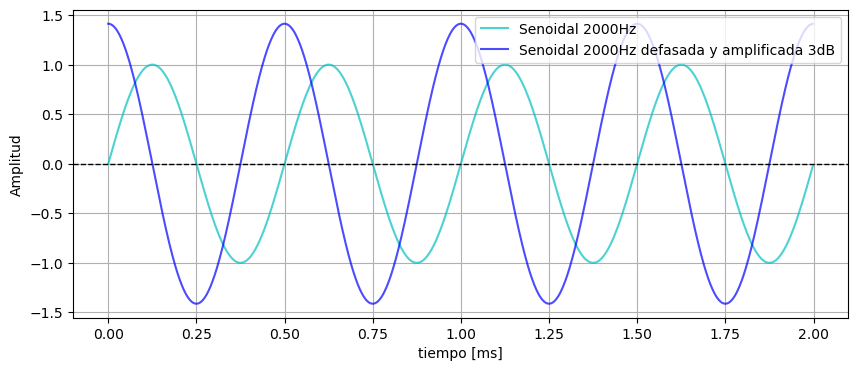

Tiempo entre muestras: 2e-06
Periodo: 0.0005
Cantidad de muestras: 1000
Potencia sen azul: 0.5000000000000001
Potencia sen naranja: 0.9976311574844398


In [29]:
# Parámetros 1
A = 1 
dc = 0              #valor medio [Volts]
f0 = 2000           #frecuencia [Hz]
fase = 0            #[radianes]
muestras = 1000     #[#]muestras tomadas por ADC
fs = 500000         #frecuencia de muestreo del ADC

# Llamada a la funcion
tt1, xx1 = mi_funcion_sen(A, dc, f0, fase, muestras, fs)

#paso tiempo a milisegundos
tt1 = tt1*1000

#-------------------------------------------------------------
# Amplificada en amplitud 3dB y 
#-------------------------------------------------------------
#cada vez que subo 3db esttoy dupplicando la potencia
#la senal en aplitud esta en voltios
# Factor de escala para amplitud (se usa 20 porque es voltaje/amplitud)
#db = 10.log10(P1/P2)
# P(potencia) = (v**2)/R => se simplifican las R en el cociente 
# => dB = 10.log10(v2/v1)**2 => dB = 2.10.log10(v2/v1)
# => v2 = 10**(3dB/20)
ganancia_db = 3
factor_amplitud = 10**(ganancia_db / 20) 


# Parámetros 2
A2 = A*factor_amplitud  # amplitud [Volts]
dc = 0                  #valor medio [Volts]
f0 = 2000               #frecuencia [Hz]
fase = np.pi/2          #[radianes]
muestras = 1000         #[#]muestras tomadas por ADC
fs = 500000             #frecuencia de muestreo del ADC

# Llamada a la funcion
tt2, xx2 = mi_funcion_sen(A2, dc, f0, fase, muestras, fs)

#paso tiempo a milisegundos
tt2 = tt2*1000


# Gráfico
plt.figure(figsize=(10, 4))
plt.plot(tt1, xx1, 'c', label="Senoidal 2000Hz", alpha=0.7)
plt.plot(tt2, xx2, 'b', label="Senoidal 2000Hz defasada y amplificada 3dB", alpha=0.7)
plt.xlabel("tiempo [ms]")
plt.ylabel("Amplitud")
plt.axhline(0,color = 'k', linestyle='--', linewidth=1)
plt.grid(True)
plt.legend()
plt.show()

print(f"Tiempo entre muestras: {1/fs}")
print(f"Periodo: {1/f0}")
print(f"Cantidad de muestras: {muestras}")
print(f"Potencia sen azul: {np.mean(xx1**2)}")
print(f"Potencia sen naranja: {np.mean(xx2**2)}")

Expreso sus potencias al tratarse de una señal infinita

#### 3. Misma señal modulada en amplitud por otra señal sinusoidal de frecuencia de 1000 KHz.

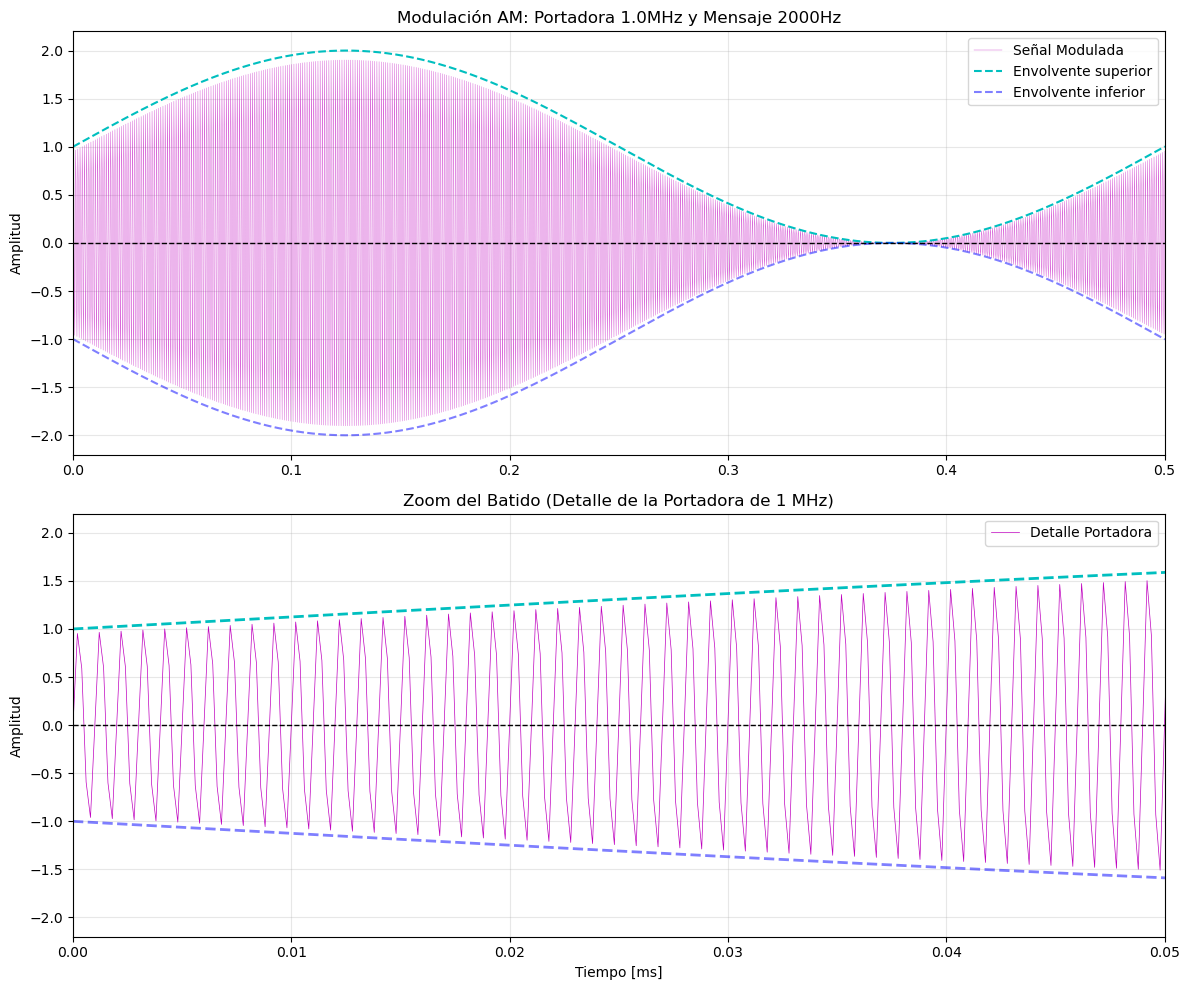

Tiempo entre muestras 2e-07
Periodo moduladora: 0.0005
Periodo portadora: 1e-06
Cantidad de muestras: 5000
Potencia (señal infinita) 0.7499999999999996


In [30]:
# %% modulada en amplitud
'''#Parámetros moduladora
fm = (f0/2) *1000       # Frecuencia moduladora ( MUY lenta)
           # Amplitud de la moduladora
# Parámetros moduladora
am= A                   # amplitud [Volts]
dc = 0                  #valor medio [Volts]
fm = 1000000            # Frecuencia moduladora ( MUY lenta)
fase = 0                #[radianes]
muestras = 10000         #[#]muestras tomadas por ADC
fs = 2500000

# Señal Moduladora
tt_m, xx_m = mi_funcion_sen(1, dc, f0, fase, muestras, fs)
xx_m = xx_m + am

tt3, xx3 = mi_funcion_sen(A, dc, fm, fase, muestras, fs)

# nueva señal (modulada)
xx_p = xx_m * xx3'''

# --- VALORES AJUSTADOS ---
f0 = 2000          # señal original (2 kHz)
fm = 1000000       # Nueva moduladora (1 MHz)

# Para ver 1 MHz, necesito una fs gigante
fs = 5000000       # 5 MHz de muestreo
muestras = 5000    

# Llamadas a la función
tt_m, xx_m = mi_funcion_sen(1, 0, f0, 0, muestras, fs) # Invertí los roles para que tenga sentido visual
xx_m = xx_m + A

tt3, xx3 = mi_funcion_sen(A, 0, fm, 0, muestras, fs) # La de 1MHz es la rápida
xx_p = xx_m * xx3

#paso tiempo a milisegundos
tt_m = tt_m*1000

# ==========================================
# GRÁFICO DE MODULACIÓN: VISTA GENERAL Y ZOOM
# ==========================================
plt.figure(figsize=(12, 10))

# --- Subplot 1: Vista General (La Envolvente) ---
plt.subplot(2, 1, 1)
plt.plot(tt_m, xx_p, 'm', label='Señal Modulada', linewidth=0.3, alpha=0.7)
plt.plot(tt_m, xx_m, 'c--', label='Envolvente superior', linewidth=1.5)
plt.plot(tt_m, -xx_m, 'b--', label='Envolvente inferior', linewidth=1.5, alpha=0.5)

plt.title(f"Modulación AM: Portadora {fm/1e6}MHz y Mensaje {f0}Hz")
plt.ylabel("Amplitud")
plt.xlim(0, 0.5) # Vista de medio milisegundo para ver la forma lenta
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

# --- Subplot 2: Zoom (El Batido / Portadora) ---
plt.subplot(2, 1, 2)
plt.plot(tt_m, xx_p, 'm', label='Detalle Portadora', linewidth=0.5)
plt.plot(tt_m, xx_m, 'c--', linewidth=2)
plt.plot(tt_m, -xx_m, 'b--', linewidth=2, alpha=0.5)

plt.title("Zoom del Batido (Detalle de la Portadora de 1 MHz)")
plt.xlabel("Tiempo [ms]")
plt.ylabel("Amplitud")
# Ajustamos el ZOOM entre 0 y 0.05 ms para ver los ciclos rápidos
plt.xlim(0, 0.05) 
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout() # Para que no se pisen los títulos con los ejes
plt.show()

print(f"Tiempo entre muestras {1/fs}")
print(f"Periodo moduladora: {1/f0}")
print(f"Periodo portadora: {1/fm}")
print(f"Cantidad de muestras: {muestras}")
print(f"Potencia (señal infinita) {np.mean(xx_p**2)}")

Realicé un intercambio de papeles entre la señal moduladora y la portadora para que el gráfico tome sentido ya necesito de una señal portadora de frecuencia notablemente menor que la modulada para que pueda envolver óptimameente a esta. 

#### 4. Misma señal con efecto de saturación al 75% de su amplitud (Uso numpy.clip()).

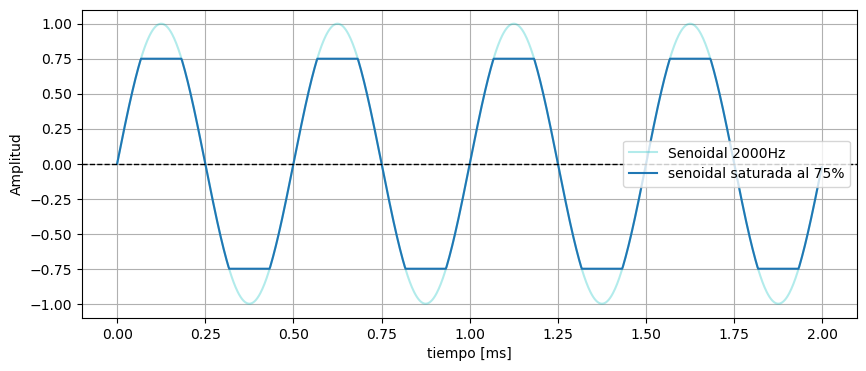

Tiempo entre muestras: 2e-07
Periodo: 0.0005
Cantidad de muestras: 1000
Potencia (Varianza): 0.370845


In [31]:
#%% Efecto de saturaci[on al 75%

# 1. Ajuste de Amplitud al 75%         
am75 = A * 0.75

xx_sat = np.clip(xx1, -am75, am75)

# Gráfico
plt.figure(figsize=(10, 4))
plt.plot(tt1, xx1,'c', label="Senoidal 2000Hz", alpha=0.3)
plt.plot(tt1, xx_sat, label="senoidal saturada al 75%")
plt.xlabel("tiempo [ms]")
plt.ylabel("Amplitud")
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.grid(True)
plt.legend()
plt.show()

# 5. Cálculos solicitados
print(f"Tiempo entre muestras: {1/fs}")
print(f"Periodo: {1/f0}")
print(f"Cantidad de muestras: {len(xx_sat)}")
print(f"Potencia (Varianza): {np.mean(xx_sat**2):.6f}")

#### 5. Una señal cuadrada de 4KHz.

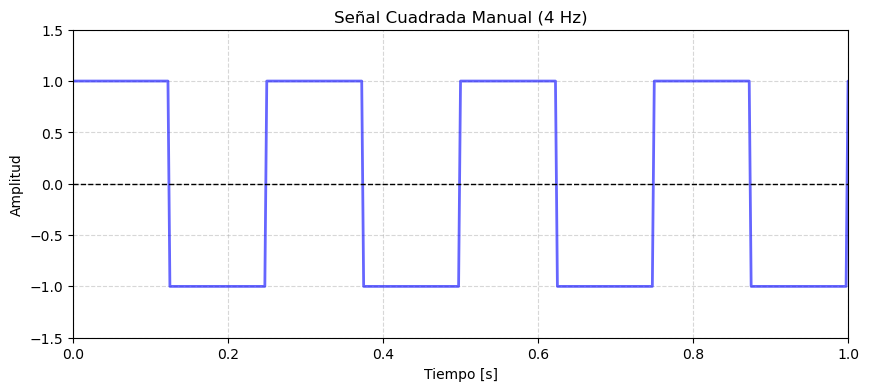

Tiempo entre muestras: 0.0025
Periodo: 0.25
Cantidad de muestras: 1000
Potencia (Varianza): 1.000000


In [33]:
# %% onda cuadrada-> Señal Cuadrada Manual
f_cuad = 4           # Frecuencia en Hz
A_cuad = 1           # Amplitud (pico)
fs = f_cuad *100     # Muestreo (el mismo que antes)
muestras = 1000      # Cantidad de puntos

# 1. Generar el vector de tiempo
t_cuad = np.arange(0, muestras) * (1/fs)

# 2. Calcular el Periodo
T = 1 / f_cuad

# 3. Lógica del "Diente de sierra" para la cuadrada
# np.mod(t_cuad, T) nos da la posición dentro del ciclo actual (va de 0 a T)
# Si estamos en la primera mitad (T/2), vale A, sino -A.
xx_cuadrada = np.where(np.mod(t_cuad, T) < (T / 2), A_cuad, -A_cuad)

# --- Gráfico ---
plt.figure(figsize=(10, 4))
plt.plot(t_cuad, xx_cuadrada, color='blue', lw=2, alpha = 0.6)
plt.xlim(0, 1)

plt.title(f"Señal Cuadrada Manual ({f_cuad} Hz)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.ylim(-1.5, 1.5) # Margen para que no toque los bordes del gráfico
plt.show()

# 5. Cálculos solicitados
print(f"Tiempo entre muestras: {1/fs}")
print(f"Periodo: {1/f_cuad}")
print(f"Cantidad de muestras: {len(xx_cuadrada)}")
print(f"Potencia (Varianza): {np.mean(xx_cuadrada**2):.6f}")

#### 6. Un pulso rectangular de 10ms.

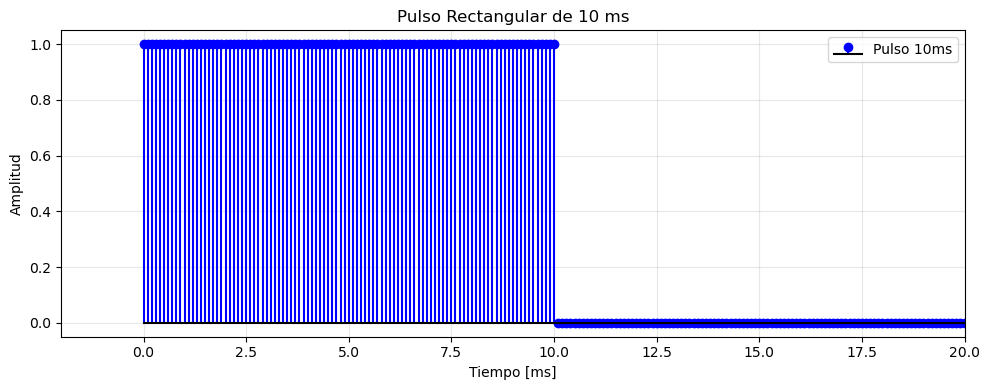

Muestras totales en el pulso: 100
Energia: 0.202000


In [34]:
# %% pulso 10ms

fs = 10000              # Frecuencia de muestreo (10 kHz)
ts = 1/fs               # Tiempo entre muestras
duracion_pulso = 0.010  # 10 ms
tiempo_total = 0.050    # 50 ms para ver el contexto

# Vector de tiempo
tt = np.arange(0, tiempo_total, ts)

# Creo un vector de ceros y pongo en 1 donde el tiempo sea < 10ms
pulso = np.where(tt <= duracion_pulso, 1.0, 0.0)

#grafico
plt.figure(figsize=(10, 4))
plt.stem(tt * 1000, pulso, linefmt='b', markerfmt='bo',
         basefmt='k-', label='Pulso 10ms')
plt.title('Pulso Rectangular de 10 ms')
plt.xlabel('Tiempo [ms]')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.legend()

# Ajusto el eje X 
plt.xlim([-2, 20]) 
plt.tight_layout()
plt.show()

# --- VERIFICACIÓN ---
print(f"Muestras totales en el pulso: {int(duracion_pulso * fs)}")

print(f"Energia: {np.mean(pulso**2):.6f}")

Expreso su energia al tratarse de un pulso ùnico y delimitado

### Ejercicio 2: Dado h[n] = δ[n] - δ[n - 4], encontrar y[n] = x[n] * h[n] para cada una de las siguientes x[n]:
Presento primero mis estimaciones hechas a mano y luego el còdigo que lo verifica

#### 1. x[n] = cos(ω₀.n. TS). Expresar la respuesta como un único coseno de la forma A cos(ω₀. n . TS + φ).

<img src="./Convolucion1_ts1.png" width="700"> 

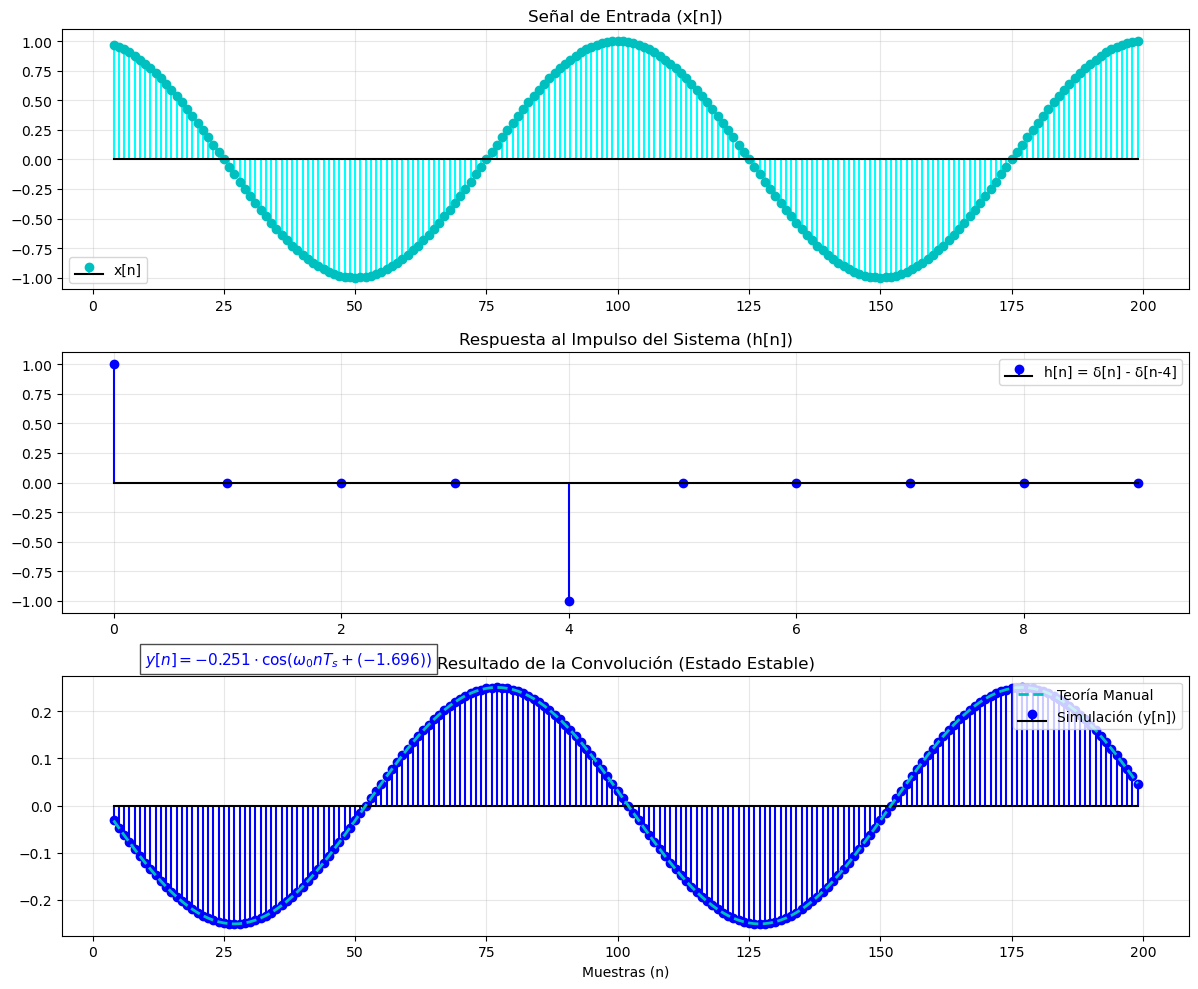

Amplitud máxima en el gráfico: 0.2507
Amplitud teórica calculada (A): 0.2507


In [26]:
# %% convolucion 1
# ==========================================
# 1. PARÁMETROS DEL SISTEMA
# ==========================================
f0 = 1                   # Frecuencia de la señal (1 Hz)
fs = 100                 # Frecuencia de muestreo (100 muestras/seg)
T_s = 1/fs               # Periodo de muestreo
w0 = 2 * np.pi * f0      # Frecuencia angular

# ==========================================
# 2. DEFINICIÓN DE x[n] 
# ==========================================
# Genero más muestras de las que vamos a graficar para evitar errores de borde
n_total = np.arange(0, 300) 
x_n = np.cos(w0 * n_total * T_s)

# ==========================================
# 3. DEFINICIÓN DE h[n] (SISTEMA)
# ==========================================
# h[n] = delta[n] - delta[n-4]
h_n = np.zeros(10)
h_n[0] = 1
h_n[4] = -1

# ==========================================
# 4. CONVOLUCIÓN SIN MOVER NADA (CORREGIDO)
# ==========================================
y_full = np.convolve(x_n, h_n, mode='full')

# En lugar de y_full[4:], tomo los datos DESDE el inicio 
# pero sé que los primeros 4 son el transitorio.
# Para que la teoría coincida, graficamos y_full contra un eje n desplazado
n_salida = np.arange(len(y_full)) 

# Para la validación, tomo un rango donde el sistema ya es estable
# pero respetando su posición original en el tiempo.
inicio = 4
fin = 200
n_estable = n_salida[inicio:fin]
y_estable = y_full[inicio:fin]

# ==========================================
# 5. GRÁFICOS 
# ==========================================
plt.figure(figsize=(12, 10))

# Subplot 1: Entrada x[n] (Color Cian)
plt.subplot(3, 1, 1)
plt.stem(n_estable, x_n[inicio:fin], linefmt='cyan', markerfmt='co', 
         label='x[n]', basefmt='k-')
plt.title('Señal de Entrada (x[n])')
plt.grid(True, alpha=0.3)
plt.legend()

# Subplot 2: Respuesta al Impulso h[n] (Color Blue)
plt.subplot(3, 1, 2)
n_h = np.arange(10)
plt.stem(n_h, h_n[:10], linefmt='blue', markerfmt='bo',
         label='h[n] = δ[n] - δ[n-4]', basefmt='k-')
plt.title('Respuesta al Impulso del Sistema (h[n])')
#plt.xticks(n_h)
plt.grid(True, alpha=0.3)
plt.legend()

# Subplot 3: Resultado y[n] con VALIDACIÓN
plt.subplot(3, 1, 3)

# 1. Graficamos los puntos de la simulación
plt.stem(n_estable, y_estable, linefmt='b', markerfmt='b',
         label='Simulación (y[n])', basefmt='k-')

# ---VALIDACIÓN con lo sacado manualmente ---

A_man = -2 * np.sin(2 * w0 * T_s)
phi_man = -2 * w0 * T_s - np.pi/2
y_teorica = A_man * np.cos(w0 * n_estable * T_s + phi_man)

# 2. Grafico la línea teórica encima
plt.plot(n_estable, y_teorica, 'c--', linewidth=2, label='Teoría Manual')

# 3. Añado el texto con la fórmula
label_formula = r'$y[n] = %.3f \cdot \cos(\omega_0 n T_s + (%.3f))$' % (A_man, phi_man)

# Colocamos el texto en n=10, y una altura un poco mayor a la amplitud
plt.text(10, abs(A_man) * 1.2, label_formula, fontsize=11, color='b', 
         bbox=dict(facecolor='white', alpha=0.7))

# -----------------------------
plt.title('Resultado de la Convolución (Estado Estable)')
plt.xlabel('Muestras (n)')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()



# ==========================================
# 6. CÁLCULO ANALÍTICO (Para tu consigna)
# ==========================================
A_teorica = np.abs(2 * np.sin(2 * w0 * T_s))
print(f"Amplitud máxima en el gráfico: {np.max(y_estable):.4f}")
print(f"Amplitud teórica calculada (A): {A_teorica:.4f}")



Se puede evidenciar que el resultado final estuvo acertado, aunque el eje de abscisas a mano lo exprese como si se tratase de frecuencia 1/100 en lugar de T=100. En el gráfico podemos evidenciar en principio la señal x, luego la señal h de deltas y luego su convolución.

#### 2. x[n] = (1/2)ⁿ u[n].

<img src="./Convolucion2_ts1.png" width="700"> 

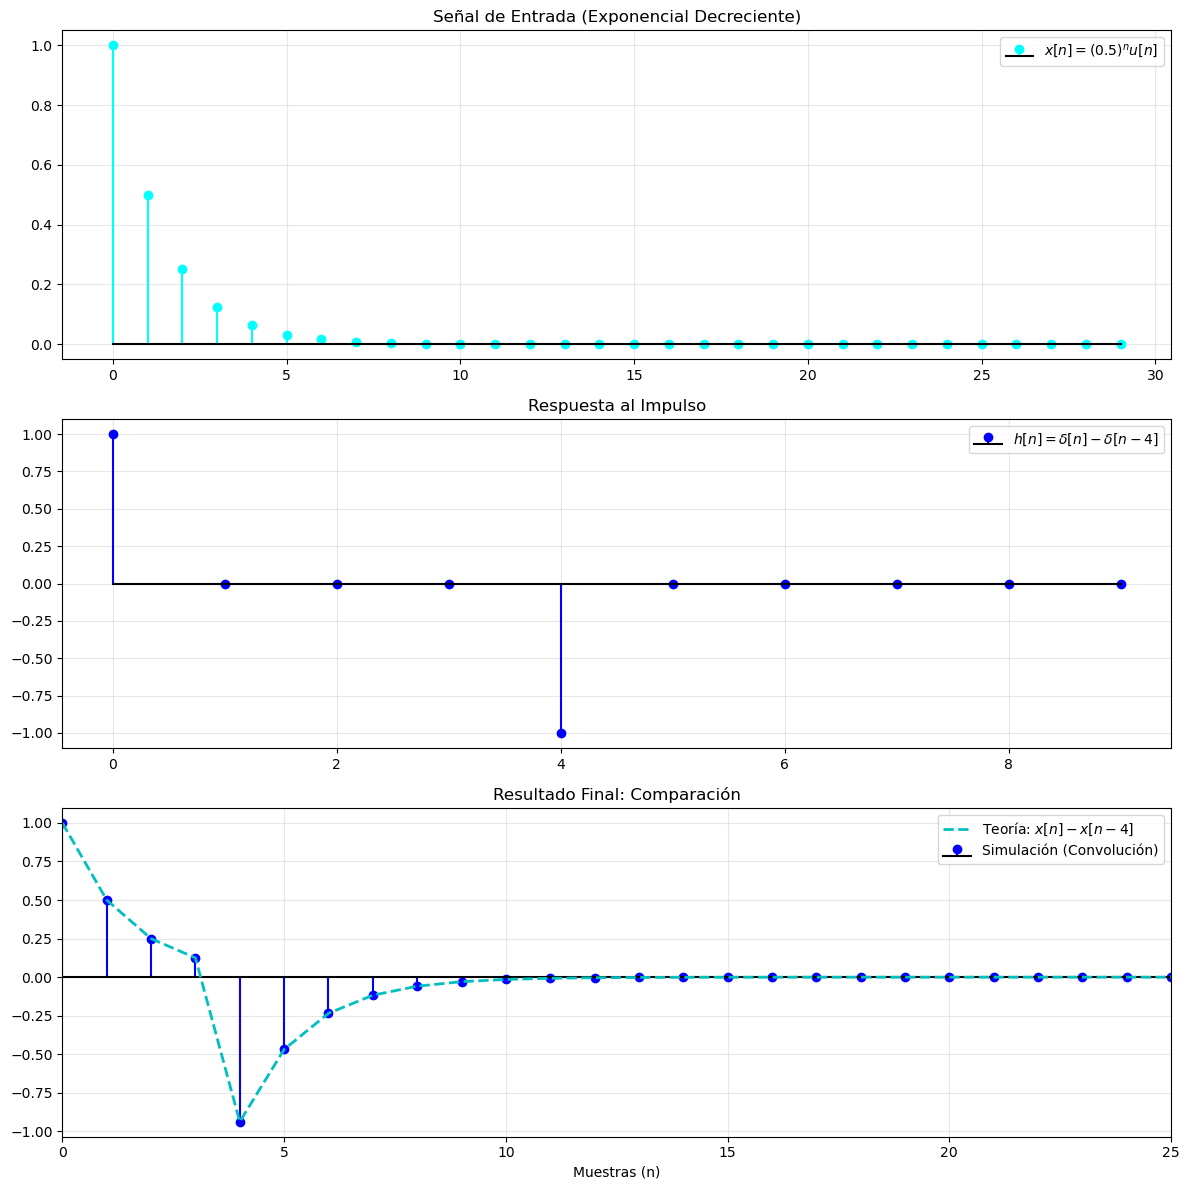

In [27]:
#%% convolucion 2

# ==========================================
# 1. PARÁMETROS
# ==========================================
fs = 1                   # En señales discretas puras, fs = 1
n = np.arange(0, 30)     # 30 muestras son suficientes para ver la caída

# ==========================================
# 2. DEFINICIÓN DE x[n] 
# ==========================================

# En Python, (n >= 0) hace la función del escalón u[n]
x_n = (0.5**n) * (n >= 0).astype(float)

# ==========================================
# 3. DEFINICIÓN DE h[n] 
# ==========================================
# h[n] = delta[n] - delta[n-4]
h_n = np.zeros(10)
h_n[0] = 1
h_n[4] = -1

# ==========================================
# 4. CONVOLUCIÓN Y VALIDACIÓN MANUAL
# ==========================================
# Simulación
y_sim = np.convolve(x_n, h_n, mode='full')
n_y = np.arange(len(y_sim))

# Cuenta Manual: y[n] = (0.5)^n u[n] - (0.5)^(n-4) u[n-4]
def y_manual_func(n_val):
    term1 = (0.5**n_val) * (n_val >= 0)
    term2 = (0.5**(n_val - 4)) * (n_val >= 4)
    return term1 - term2

y_teorica = y_manual_func(n_y)

# ==========================================
# 5. GRÁFICOS
# ==========================================
plt.figure(figsize=(12, 12))

# Subplot 1: Entrada x[n]
plt.subplot(3, 1, 1)
plt.stem(n, x_n, linefmt='cyan', markerfmt='cyan',
         label='$x[n] = (0.5)^n u[n]$', basefmt='k-')
plt.title('Señal de Entrada (Exponencial Decreciente)')
plt.grid(True, alpha=0.3)
plt.legend()

# Subplot 2: Sistema h[n]
plt.subplot(3, 1, 2)
plt.stem(np.arange(10), h_n, linefmt='blue', markerfmt='blue',
         label='$h[n] = \delta[n] - \delta[n-4]$', basefmt='k-')
plt.title('Respuesta al Impulso')
plt.grid(True, alpha=0.3)
plt.legend()

# Subplot 3: Resultado (Simulación vs Teoría)
plt.subplot(3, 1, 3)
plt.stem(n_y, y_sim, linefmt='b', markerfmt='bo',
         label='Simulación (Convolución)', basefmt='k-')
plt.plot(n_y, y_teorica, 'c--', linewidth=2,
         label='Teoría: $x[n] - x[n-4]$')
plt.title('Resultado Final: Comparación')
plt.xlabel('Muestras (n)')
plt.xlim(0, 25)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Se puede evidenciar que la estimación realizada a mano mantiene una alta similitud con la simulación hecha en python

#### 3. x[n] = u[n + 1] - u[n - 2].

<img src="./Convolucion3_ts1.png" width="700"> 

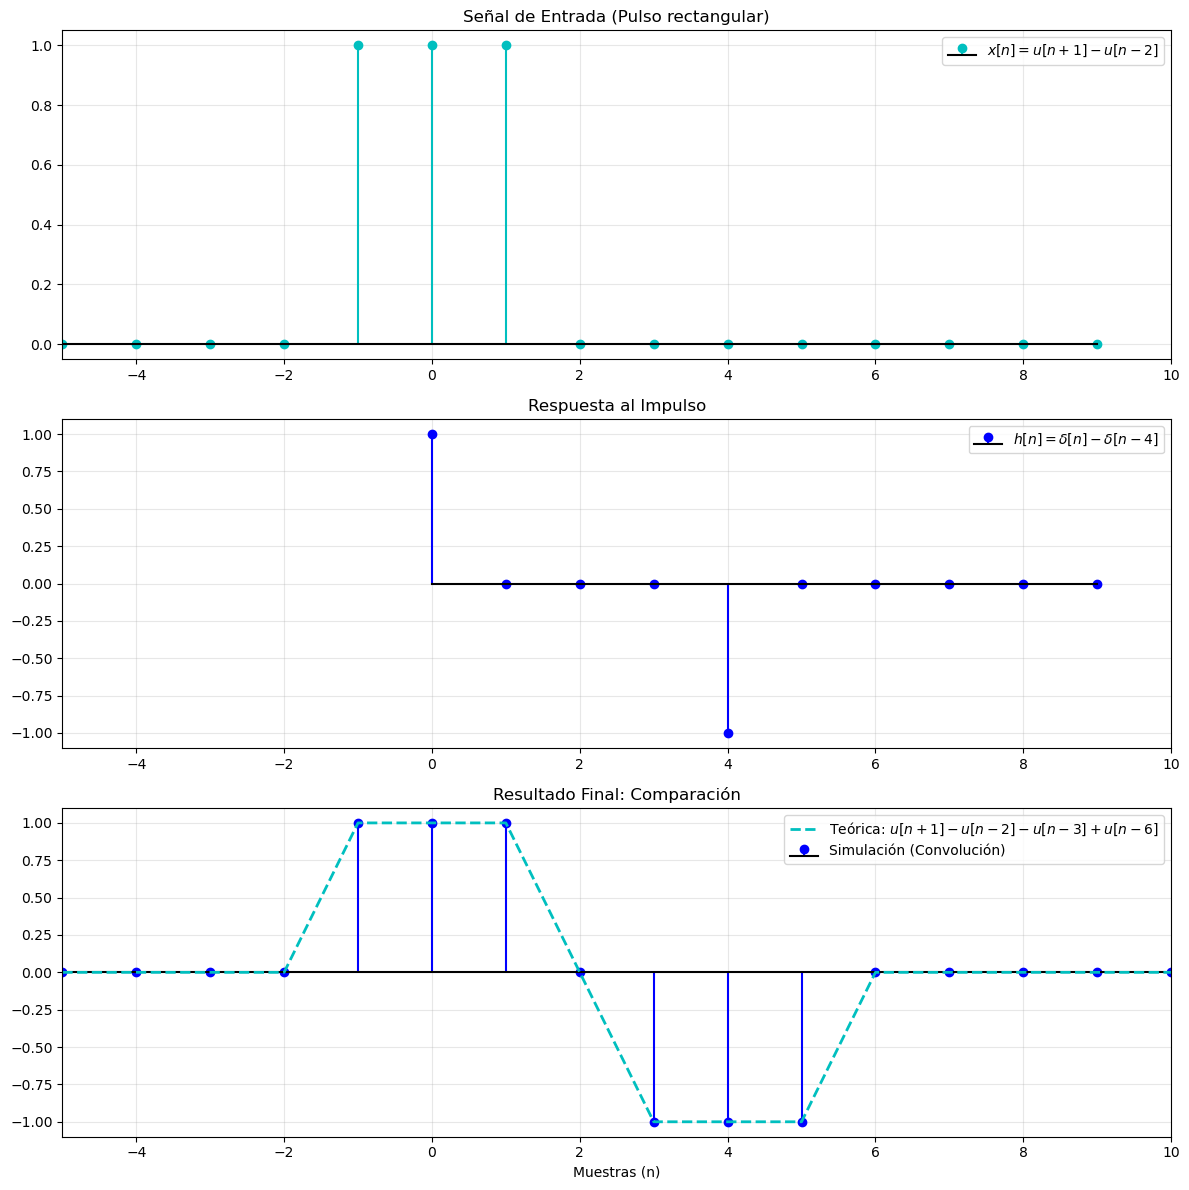

In [35]:
#%% convolucion 3
# ==========================================
# 1. PARÁMETROS
# ==========================================
n = np.arange(-5, 10)

# ==========================================
# 2. DEFINICIÓN DE x[n] 
# ==========================================
# x[n] = u[n+1] - u[n-2]
# El pulso vale 1 en n = -1, 0, 1
x_n = ((n + 1) >= 0).astype(float) - ((n - 2) >= 0).astype(float)

# ==========================================
# 3. DEFINICIÓN DE h[n] (SISTEMA)
# ==========================================
# h[n] = delta[n] - delta[n-4]
h_n = np.zeros(10)
h_n[0] = 1
h_n[4] = -1

# ==========================================
# 4. CONVOLUCIÓN Y VALIDACIÓN MANUAL
# ==========================================
y_sim = np.convolve(x_n, h_n, mode='full')
n_y = np.arange(n[0], n[0] + len(y_sim)) # Ajustamos el eje para n=-5

# Mi fórmula a mano: u[n+1] - u[n-2] - u[n-3] + u[n-6]
def u_d(val): return (val >= 0).astype(float)
y_teorica = u_d(n_y+1) - u_d(n_y-2) - u_d(n_y-3) + u_d(n_y-6)


# ==========================================
# 5. GRÁFICOS
# ==========================================
plt.figure(figsize=(12, 12))

# Subplot 1: Entrada x[n]
plt.subplot(3, 1, 1)
plt.stem(n, x_n, linefmt='c', markerfmt='co', label='$x[n] = u[n+1] - u[n-2]$' , basefmt='k-')
plt.title('Señal de Entrada (Pulso rectangular)')
plt.xlim(-5, 10)
plt.grid(True, alpha=0.3)
plt.legend()

# Subplot 2: Sistema h[n]
plt.subplot(3, 1, 2)
plt.stem(np.arange(10), h_n, linefmt='b', markerfmt='bo', 
         label='$h[n] = \delta[n] - \delta[n-4]$', basefmt='k-')
plt.title('Respuesta al Impulso')
plt.xlim(-5, 10)
plt.grid(True, alpha=0.3)
plt.legend()

# Subplot 3: Resultado (Simulación vs Teoría)
plt.subplot(3, 1, 3)
plt.stem(n_y, y_sim, linefmt='b', markerfmt='bo', label='Simulación (Convolución)', basefmt='k-')
plt.plot(n_y, y_teorica, 'c--', linewidth=2, label='Teórica: $u[n+1]-u[n-2]-u[n-3]+u[n-6]$')
plt.title('Resultado Final: Comparación')
plt.xlabel('Muestras (n)')
plt.xlim(-5, 10)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Se puede evidenciar que la estimación realizada a mano mantiene una alta similitud con la simulación hecha en python